#**ASSIGNMENT 5: FACE RECOGNITION**  

------------------------------------------
Student Name: Varshitha Venkatesh

A\#: 

e-mail: 

-----------------------------------------
Face recognition technology has become an integral part of modern security and identification systems. In this assignment, you will develop a face recognition system that tackles the challenge of identifying individuals from a database of known faces.

Your system will operate on a database containing K face images, each associated with a unique ID. The primary task is to perform 1:K matching, where a given face image is compared against all K faces in the database to determine the identity of the individual.
It's important to distinguish face recognition from two related concepts:
*  Face Detection: This process involves locating and marking one or more faces within an image, typically by drawing bounding boxes around them.
* Face Verification: This is a 1:1 matching problem, where an input face is compared directly to a single known face image to confirm identity.

While these concepts are related, our focus will be on the more complex face recognition problem, which involves matching an input face against multiple known faces to establish identity.

The key objectives of this assignment include:
* **Leveraging Convolutional Neural Networks (CNNs) as Encoders/Feature Extractors:** You will explore the power of CNNs in extracting meaningful features from facial images. This objective involves understanding how CNNs can transform raw pixel data into high-dimensional feature vectors that capture essential facial characteristics.
* **Implementation of Siamese Networks:** This objective focuses on understanding and implementing Siamese network architectures. You'll learn how these networks can process pairs of images to determine their similarity. You'll explore the network's ability to learn a feature space where images of the same person are close together, while images of different people are far apart.
* **Utilizing Triplet Loss:** You'll delve into the concept of triplet loss and its application in face recognition. This objective involves understanding how triplet loss can be used to train your network to minimize the distance between an anchor and a positive sample (same person) while maximizing the distance between the anchor and a negative sample (different person).
* **Building a Simple Face Recognition Application:** As a culmination of your learning, you'll develop a functional face recognition application. This objective involves integrating all the components you've learned about - the CNN feature extractor, Siamese network architecture, and triplet loss - into a cohesive system. You'll create an interface that allows users to input a face image and match it against a database of known faces.

There are **three activities** for you to complete. You can comiplete the activities in the recitation on November 27 and December 4. Please use Lecture slides 20 for your reference.

**Due date:** *Please include your last name in the .ipynb file and submit the renamed file to Teams by* **December 8** *For instance, a student with the last name 'abc' would rename their file to CNN_visualizations_activities_abc.ipynb.* Your submision notebook must have all the cells executed and the outputs displayed.


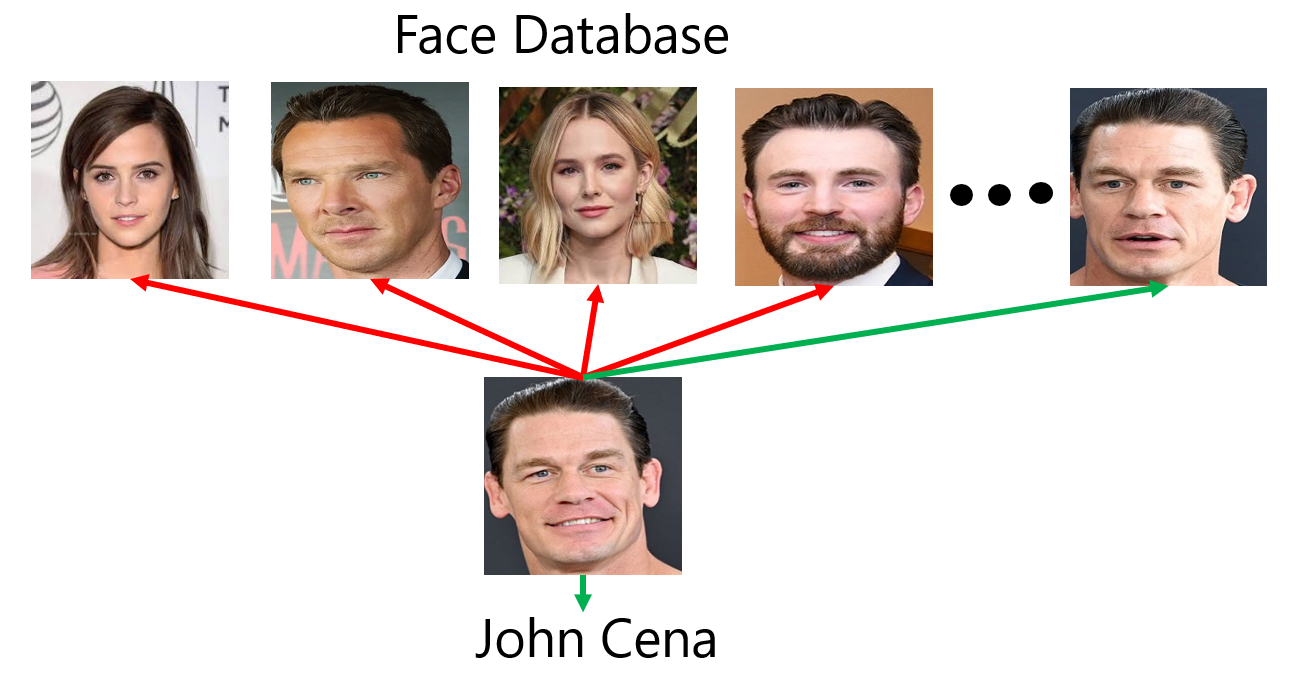

## **Naive Face Verification**

First let us consider a naive approach for Face Verification. You are given two images and you have to tell if they are of the same person. The simplest way to do this is to compare the two images pixel-by-pixel. If the distance between the raw images are less than a chosen threshold, we can declare a match!

Of course, this algorithm performs really poorly, since the pixel values change dramatically due to variations in lighting, orientation of the person's face, even minor changes in head position, and so on.

You will see that rather than using the raw image, you can learn an encoding $f(img)$ using the deep learning model so that element-wise comparisons of this encoding gives a more accurate judgements as to whether two pictures are of the same person. We will try to implement such an algorithm in this assignment.
    
**To be more specific, you will:**
- Use a pre-trained VGG16 model to map face images into 128-dimensional encodings
- Design a siamese network architecture to learn the correct feature encodings of each image.
- Optimize the triplet loss function for learning the parameters
- Use the feature encodings to perform face recognition


# **1. Dataset & Preprocessing**

Let's get started!

As usual, before executing the following python codes, you have to upload the `Face_Recognition` folder to your Google drive. Download the project from github repo and upload it into the `My Drive/Colab Notebooks` of your google drive.Then mount the google drive and set the working directory to `My Drive/Colab Notebooks/Face_Recognition`.

Before you proceed, please make sure you are using GPUs for this project. *Click Runtime at the top of the page and select (change runtime type) option. Finally select GPU from dropdown options and Save.*

In [2]:
import os
from google.colab import drive
drive.mount('/content/gdrive')
root_dir = "/content/gdrive/MyDrive/"
project_folder = "Colab Notebooks/Face_Recognition/"
os.chdir(root_dir+project_folder)

Mounted at /content/gdrive


In [3]:
!gdown --id 1mhUDB8AfPrIVoWU7dlBMORKElag1fCKE

/usr/local/lib/python3.10/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1mhUDB8AfPrIVoWU7dlBMORKElag1fCKE
From (redirected): https://drive.google.com/uc?id=1mhUDB8AfPrIVoWU7dlBMORKElag1fCKE&confirm=t&uuid=19327590-6985-491b-bca1-fc2073852f59
To: /content/gdrive/MyDrive/Colab Notebooks/Face_Recognition/dataset.7z
100% 3.11G/3.11G [00:39<00:00, 78.7MB/s]


In [6]:
!7z x dataset.7z


7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,2 CPUs Intel(R) Xeon(R) CPU @ 2.20GHz (406F0),ASM,AES-NI)

Scanning the drive for archives:
  0M Scan         1 file, 3111010699 bytes (2967 MiB)

Extracting archive: dataset.7z
--
Path = dataset.7z
Type = 7z
Physical Size = 3111010699
Headers Size = 1178243
Method = LZMA2:24
Solid = +
Blocks = 2

  0%      0% 16 - dataset/images/n000394                                  0% 61         0% 137 - dataset/images/n002581                                   0% 232 - dataset/images/n004372                                   0% 319 - dataset/images/n005373                                 

Let us import some important libraries by running the cell below required for our model and data manipulation and set the TensorFlow implementation of the Keras backend to `K`.

In [5]:
import os
import cv2
import random
import numpy as np
from tqdm import tqdm
import tensorflow as tf
from datetime import datetime
from sklearn.utils import shuffle

%load_ext tensorboard
K = tf.keras.backend


Run the following cell to check if you are using a GPU. You will get a message `Found GPU at: /device:GPU:0` if you have selected GPU for the whole processing.

In [7]:
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
    raise SystemError('GPU device not found')
print('Found GPU at: {}'.format(device_name))

Found GPU at: /device:GPU:0


### **1.1 The Dataset and the Pre-trained Model Weights**

For this assignment, you will work with a compressed subset of the VGGFace2 dataset, which includes 8,631 celebrity images for training and 500 for testing. After extracting the dataset.7z file, you will find an "image" folder containing subdirectories (e.g., n000001, n000009), each representing a distinct celebrity and their corresponding images. Additionally, there is a "list.txt" file in the main directory that provides a mapping of directory names to image names in the format: directory-name/image-name. This file is essential for optimizing memory usage during the training of your face recognition model. The dataset is already available under `Face_Recognition` project folder.

Training a Convolution Neural Network(CNN) from scratch takes a lot of data, time and also compute power. So we instead use **transfer learning** for this project where a model already trained on similar large dataset is fine-tuned as per our requirement. The Visual Geometry Group (VGG) at Oxford has built three models — VGG-16, ResNet-50, and SeNet-50 trained for face recognition as well as for face classification. We will  use the VGG-16 model as it is a smaller model and the real-time prediction can work on a local system with medium configuration. More information can be found from this paper here (https://www.robots.ox.ac.uk/~vgg/publications/2015/Parkhi15/parkhi15.pdf). Let us download the pretrained VGG16 weights which we will use in the image encoder later.

In [18]:
!gdown --id 1hVYxpi4RJWOQiPGSYqTAVb34DFvrg9bj

/usr/local/lib/python3.10/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Failed to retrieve file url:

	Cannot retrieve the public link of the file. You may need to change
	the permission to 'Anyone with the link', or have had many accesses.
	Check FAQ in https://github.com/wkentaro/gdown?tab=readme-ov-file#faq.

You may still be able to access the file from the browser:

	https://drive.google.com/uc?id=1hVYxpi4RJWOQiPGSYqTAVb34DFvrg9bj

but Gdown can't. Please check connections and permissions.


### **1.2 The Preprocessing**

The function, `preprocess_input(..)`, is designed to preprocess image data for our model. It takes an input array `x`, a data format specification, and a version number. The function first creates a copy of the input to avoid modifying the original data. It then checks and handles different channel orders (channels_first or channels_last). Depending on the version (1 or 2), it reverses the order of color channels and subtracts specific mean values from each channel. The version numbers are (versions 1 and 2) related to different preprocessing strategies with specific mean values (observe that mean values differ between versions). This preprocessing step is crucial for normalizing the input data to match the expectations of pre-trained models, ensuring consistent and optimal performance in image recognition tasks.

In [8]:


def preprocess_input(x, data_format=None, version=1):
    x_temp = np.copy(x)
    if data_format is None:
        data_format = K.image_data_format()
    assert data_format in {'channels_last', 'channels_first'}

    if version == 1:
        if data_format == 'channels_first':
            x_temp = x_temp[:, ::-1, ...]
            x_temp[:, 0, :, :] -= 93.5940
            x_temp[:, 1, :, :] -= 104.7624
            x_temp[:, 2, :, :] -= 129.1863
        else:
            x_temp = x_temp[..., ::-1]
            x_temp[..., 0] -= 93.5940
            x_temp[..., 1] -= 104.7624
            x_temp[..., 2] -= 129.1863

    elif version == 2:
        if data_format == 'channels_first':
            x_temp = x_temp[:, ::-1, ...]
            x_temp[:, 0, :, :] -= 91.4953
            x_temp[:, 1, :, :] -= 103.8827
            x_temp[:, 2, :, :] -= 131.0912
        else:
            x_temp = x_temp[..., ::-1]
            x_temp[..., 0] -= 91.4953
            x_temp[..., 1] -= 103.8827
            x_temp[..., 2] -= 131.0912
    else:
        raise NotImplementedError

    return x_temp

The following code prepares the training environment for our model, by setting the number of epochs to 5 and configuring the Adam optimizer with a learning rate of 0.00006, along with binary cross-entropy as the loss function. It establishes directories for logging training progress and metrics, creating unique log paths using timestamps. Additionally, it sets up TensorFlow summary writers to track and record the model's performance during training and specifies a path for saving model checkpoints.

In [9]:
epochs = 5

optimizer = tf.keras.optimizers.Adam(learning_rate=0.00006)
binary_cross_entropy = tf.keras.losses.BinaryCrossentropy()

# base_dir = "."
base_dir = os.getcwd()+"/"

stamp = datetime.now().strftime("%Y%m%d-%H%M%S")
logdir = os.path.join(base_dir, 'logs/func/%s' % stamp)
writer = tf.summary.create_file_writer(logdir)

scalar_logdir = os.path.join(base_dir, 'logs/scalars/%s' % stamp)
file_writer = tf.summary.create_file_writer(scalar_logdir + "/metrics")

checkpoint_path = os.path.join(base_dir, 'logs/model/siamese')

### **1.3 The Image Triplets Generator**

Now we are going to create a data generator class that is reposible for feeding data systematically as batches to the model while training. The function will rendomly generate image triplets (A, P, N) for the training. Each triplet contains an anchor image (A), the positive image (P) and a negative (N) image.

$__getitem__()$ is designed to generate triplets for face recognition training, consisting of an Anchor (A), a Positive (P), and a Negative (N) image. We get the names of the people from the above dictionary keys. For 1st batch, the first 32 (batch size) people images are used as anchors, and a different image, of the same person, is used as positives as described below.
* **Anchor Selection:** An anchor image is randomly selected from the set of images belonging to a specific person.
* **Positive Selection:** A positive image is also randomly selected from the same person's set of images. The code ensures that the positive image is different from the anchor by using a while loop. If the randomly chosen index for the positive image matches the anchor's index, it continues to select another random index until it finds one that differs. This guarantees that the positive image is distinct from the anchor image within the same person's dataset.
* **Negative selection:**
 * First selecting a different Person. First, a random index is selected to choose a person who is different from the current person being processed. This is done using ```random.randint(0, self.no_of_people - 1)``` to pick an index from the list of people. A while loop ensures that the selected "negative person" is not the same as the "anchor person." If the randomly chosen negative person happens to be the same as the anchor person, it continues to select another random index until it finds a different person.
 * Selecting an Image from the Negative Person:
Once a different person is chosen, a random image is selected from this person's collection of images. This is done using ```random.randint(0, len(self.dataset[negative_person])-1)```. This image serves as the Negative image in the triplet.

$__init__$: The constructor takes the path to the dataset directory defined in the previous subsection. The constructor uses the list.txt to make a dictionary. This dictionary has the directory name as its key and a list of images in that directory as its value. It is here, and in the shuffling step, that the list.txt becomes an easy way for us to have a dataset overview, thus avoiding to load images for shuffling.

**curate_dataset**: Creates the dictionary explained in the $__init__$

**on_epoch_end:** On each epoch end, the order of people is shuffled, so that in the next epoch, the first 32 images are different than the one seen in the previous epoch.

**get_image:** The get image function uses the preprocess_input after resizing the image to (224 x 224) size.

$__len__$: This will return the number of batches that will define one epoch.


In [10]:

class DataGenerator(tf.keras.utils.Sequence):
    def __init__(self, dataset_path, batch_size=16, shuffle=True):
        self.dataset = self.curate_dataset(dataset_path)
        self.dataset_path = dataset_path
        self.shuffle = shuffle
        self.batch_size =batch_size
        self.no_of_people = len(list(self.dataset.keys()))
        self.on_epoch_end()

    def __getitem__(self, index):
        people = list(self.dataset.keys())[index * self.batch_size: (index + 1) * self.batch_size]
        P = []
        A = []
        N = []

        for person in people:
            anchor_index = random.randint(0, len(self.dataset[person])-1)
            a = self.get_image(person, anchor_index)

            positive_index = random.randint(0, len(self.dataset[person])-1)
            while positive_index == anchor_index:
                positive_index = random.randint(0, len(self.dataset[person])-1)
            p = self.get_image(person, positive_index)

            negative_person_index = random.randint(0, self.no_of_people - 1)
            negative_person = list(self.dataset.keys())[negative_person_index]
            while negative_person == person:
                negative_person_index = random.randint(0, self.no_of_people - 1)
                negative_person = list(self.dataset.keys())[negative_person_index]

            negative_index = random.randint(0, len(self.dataset[negative_person])-1)
            n = self.get_image(negative_person, negative_index)
            P.append(p)
            A.append(a)
            N.append(n)
        A = np.asarray(A)
        N = np.asarray(N)
        P = np.asarray(P)
        return [A, P, N]

    def __len__(self):
        return self.no_of_people // self.batch_size

    def curate_dataset(self, dataset_path):
        with open(os.path.join(dataset_path, 'list.txt'), 'r') as f:
            dataset = {}
            image_list = f.read().split()
            for image in image_list:
                folder_name, file_name = image.split('/')
                if folder_name in dataset.keys():
                    dataset[folder_name].append(file_name)
                else:
                    dataset[folder_name] = [file_name]
        return dataset

    def on_epoch_end(self):
        if self.shuffle:
            keys = list(self.dataset.keys())
            random.shuffle(keys)
            dataset_ =  {}
            for key in keys:
                dataset_[key] = self.dataset[key]
            self.dataset = dataset_

    def get_image(self, person, index):
      img_path = os.path.join(self.dataset_path, 'images', person, self.dataset[person][index])
      img = cv2.imread(img_path)
      if img is None:
          print(f"Warning: Could not load image at {img_path}. Skipping...")
          return None
      img = cv2.resize(img, (224, 224))
      img = np.asarray(img, dtype=np.float64)
      img = preprocess_input(img)
      return img


# **2.Encoding the Face Images**

In this section, we will build our main VGG16 face recognition model and understand the concept of transfer learning. You may replace VGG16 with AlexNet or other classical netwoks and redo this assignment later. Specifically, we will encode the face images into 128-dinensional vectors. The key things you need to know are:

- The VGG16 network that we are going to build uses 224x224 dimensional RGB images as its input. Specifically, inputs a face image (or batch of $m$ face images) as a tensor of shape $(m, n_H, n_W, n_C) = (m, 224, 224, 3)$
- It outputs a matrix of shape $(m, 128)$ that encodes each input face image into a 128-dimensional vector

### **2. 1 Transfer Learning**
Let us create an instance of VGG16 model architecture and use the pre-trained weights. The VGG-16 model was trained on a very large VGGface dataset, where they had trained the classification model on 2622 different faces. In the following cell, we need to load the pretrained weights of that model. The second to last layer has 4096 Dense Units to which we append a 128 unit Dense layer, without the bias term, and remove the classification/softmax layer containing 2622 units (Note that the figure shows the last layer with 1000 units, it should be 2622 units). All the layers before the 128 Dense layer are frozen (trainable = False) and only the newly added dense layer needs to be trained. This dense layer will be responsible to outputs a matrix of shape  (𝑚,128)  that encodes each input face image into a 128-dimensional vector. Refer to the provided VGG16 architecture diagram to complete Activity 1, which involves implementing these modifications to the network structure.

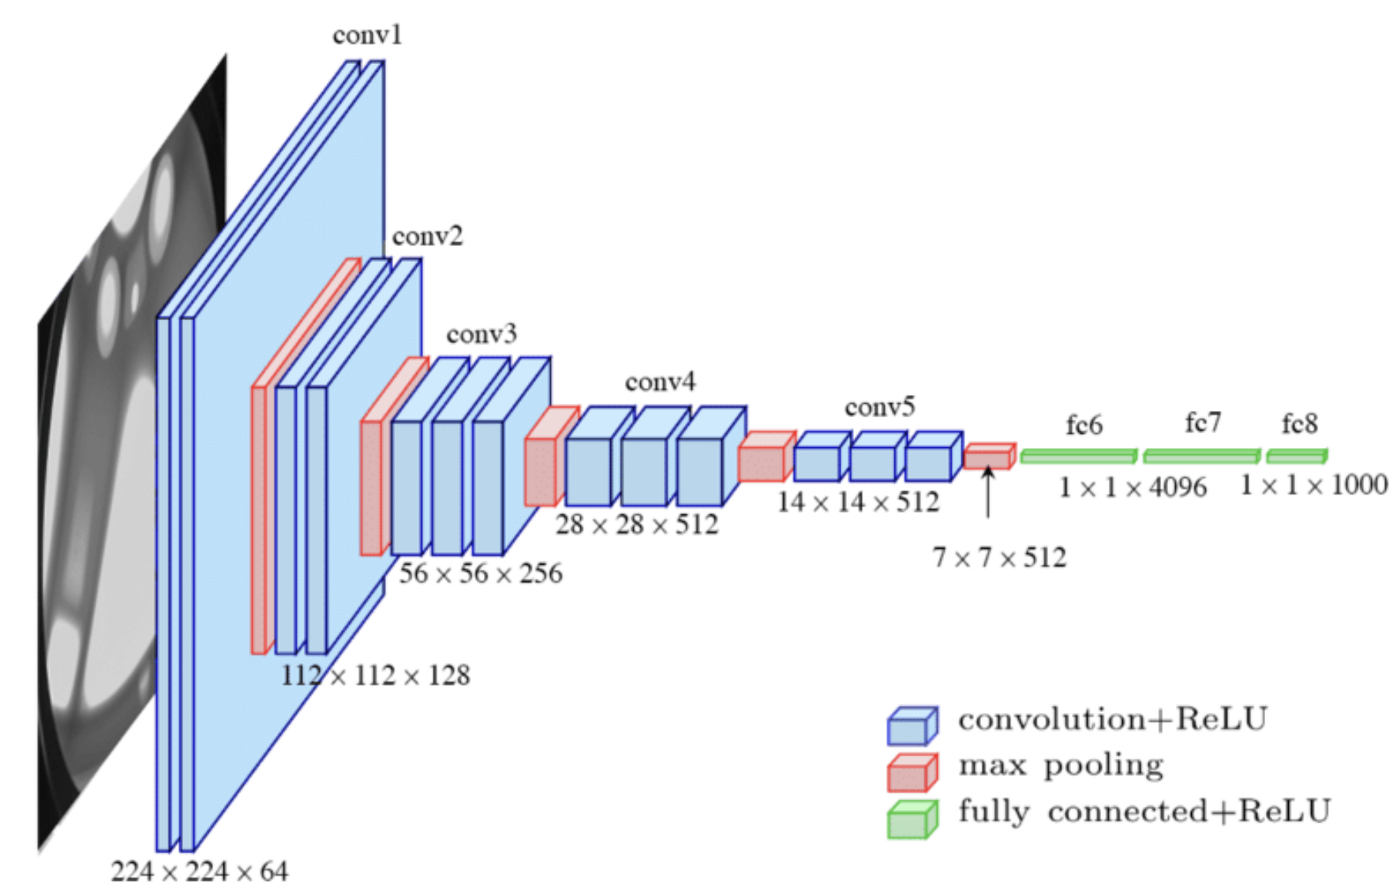

In the following cell, for building the main model you have to use `MyModel.pop()` function to remove the last layer of the VGG16 and then use `MyModel.add(tf.keras.layers.Dense(128, use_bias=False))` to append a 128 unit Dense layer, without the bias term. You may use the following model summary to complete the first activity. Please note that the convolution layers of VGG use `(3, 3)`filters with `ReLU` activation and `same` padding.

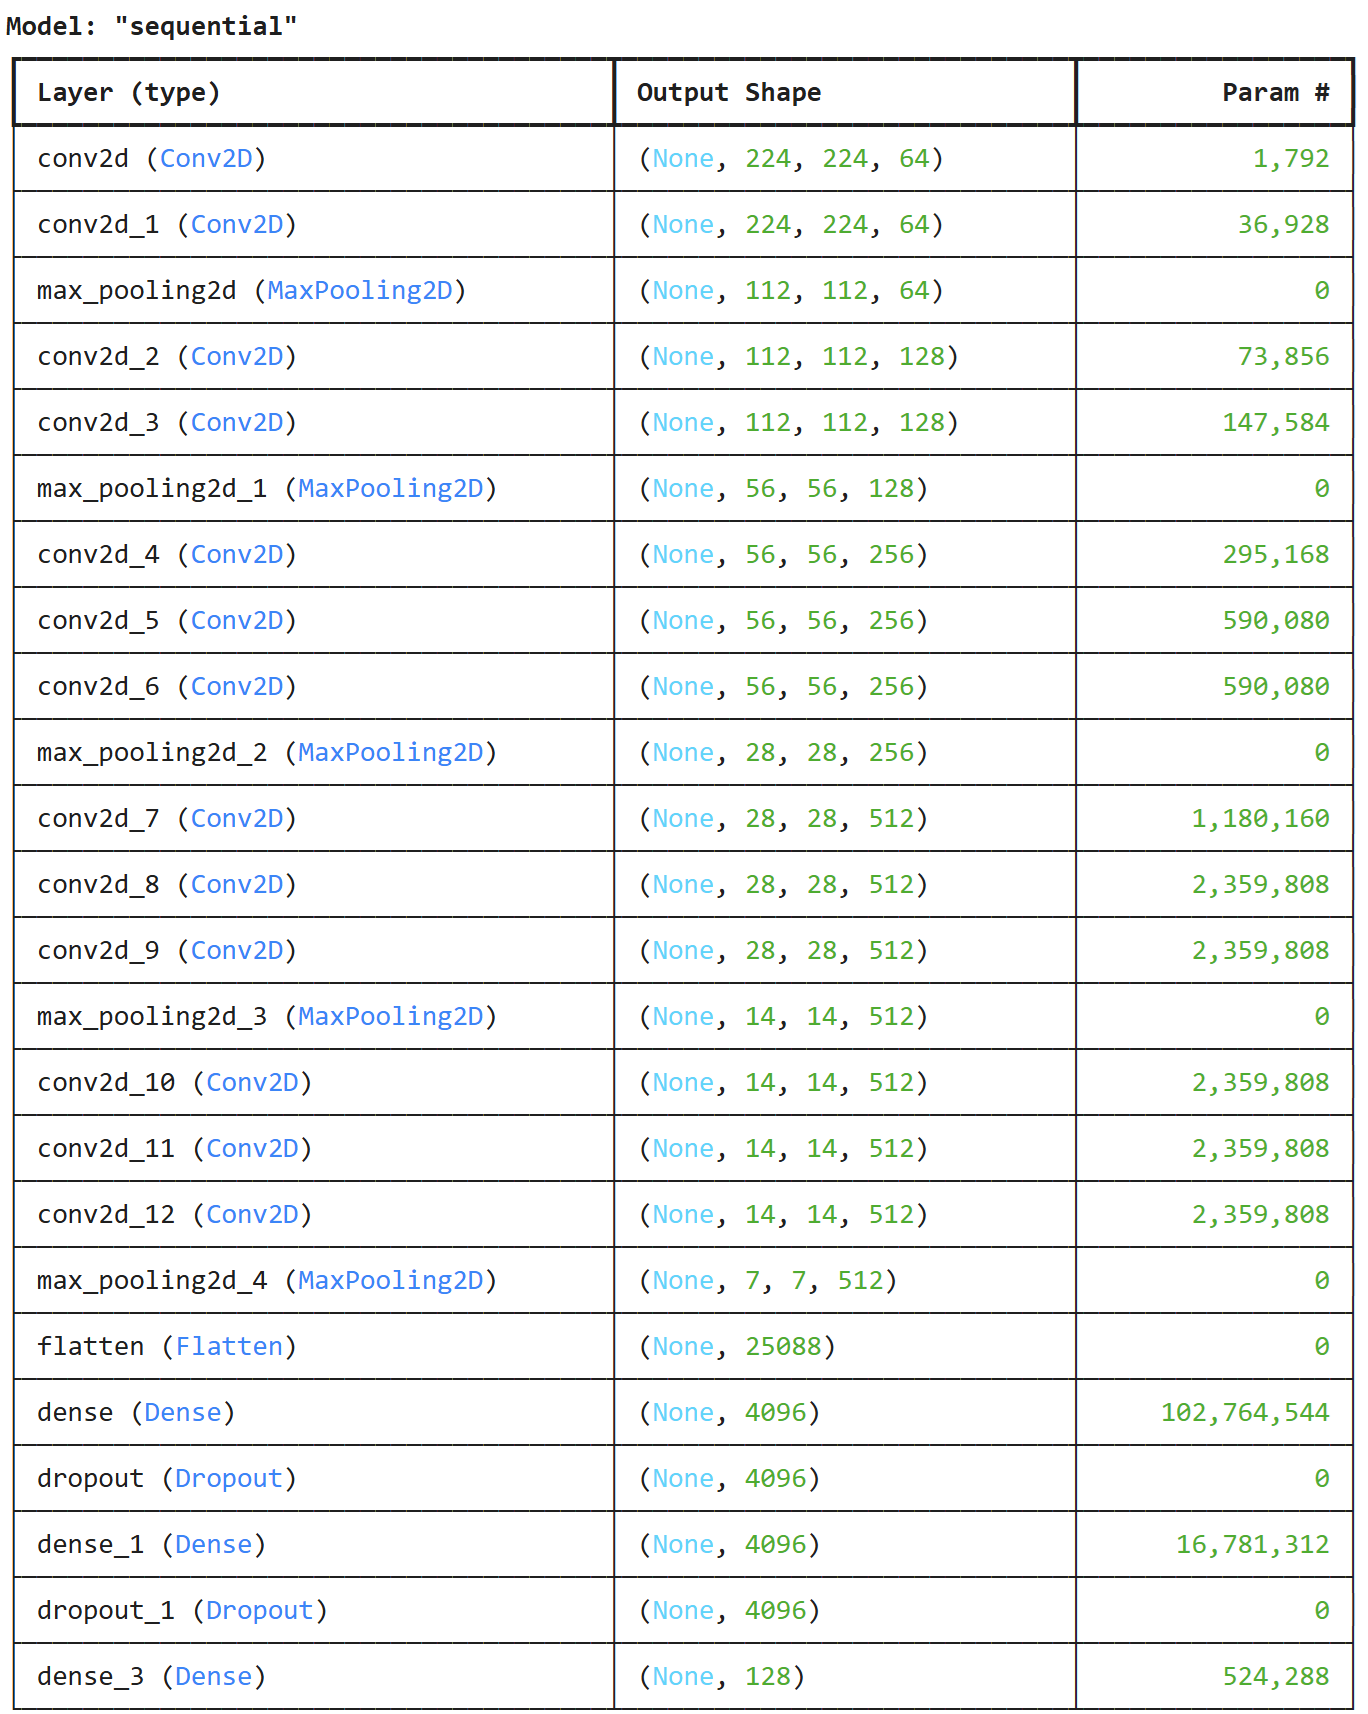

In [11]:
#Activity 1: Build the model and assign the pre-trained weights
MyModel = tf.keras.models.Sequential()

#First few convolution layers
MyModel.add(tf.keras.layers.Input(shape=(224,224, 3)))
MyModel.add(tf.keras.layers.Convolution2D(64, (3, 3), padding='same', activation='relu'))
MyModel.add(tf.keras.layers.Convolution2D(64, (3, 3), padding='same', activation='relu'))
MyModel.add(tf.keras.layers.MaxPooling2D((2,2), strides=(2,2)))

MyModel.add(tf.keras.layers.Convolution2D(128, (3, 3), padding='same', activation='relu'))
MyModel.add(tf.keras.layers.Convolution2D(128, (3, 3), padding='same', activation='relu'))
MyModel.add(tf.keras.layers.MaxPooling2D((2,2), strides=(2,2)))

#Add 5,6,7 conv layers of VGG16
MyModel.add(tf.keras.layers.Convolution2D(256, (3, 3), padding='same', activation='relu'))
MyModel.add(tf.keras.layers.Convolution2D(256, (3, 3), padding='same', activation='relu'))
MyModel.add(tf.keras.layers.Convolution2D(256, (3, 3), padding='same', activation='relu'))
MyModel.add(tf.keras.layers.MaxPooling2D((2,2), strides=(2,2)))

#Add 8,9, and 10 layers of VGG16
MyModel.add(tf.keras.layers.Convolution2D(512, (3, 3), padding='same', activation='relu'))
MyModel.add(tf.keras.layers.Convolution2D(512, (3, 3), padding='same', activation='relu'))
MyModel.add(tf.keras.layers.Convolution2D(512, (3, 3), padding='same', activation='relu'))
MyModel.add(tf.keras.layers.MaxPooling2D((2,2), strides=(2,2)))


#Add 11,12, and 13 layers of VGG16
MyModel.add(tf.keras.layers.Convolution2D(512, (3, 3), padding='same', activation='relu'))
MyModel.add(tf.keras.layers.Convolution2D(512, (3, 3), padding='same', activation='relu'))
MyModel.add(tf.keras.layers.Convolution2D(512, (3, 3), padding='same', activation='relu'))
MyModel.add(tf.keras.layers.MaxPooling2D((2,2), strides=(2,2)))

MyModel.add(tf.keras.layers.Flatten())

#Fully connected layers (14, 15 and 16)
MyModel.add(tf.keras.layers.Dense(4096, activation='relu'))
MyModel.add(tf.keras.layers.Dropout(0.5))
MyModel.add(tf.keras.layers.Dense(4096, activation='relu'))
MyModel.add(tf.keras.layers.Dropout(0.5))
MyModel.add(tf.keras.layers.Dense(2622, activation='softmax'))

#We will use the pre-trained weights for the VGG16. Let us load the pre-trained weights.
MyModel.load_weights(os.path.join(base_dir, 'PreTrained_Weight_vgg16.h5'))
#Remove the last layer of VGG16
MyModel.pop()

#Append a 128 unit dense layer without bias term (refer to the description above)
MyModel.add(tf.keras.layers.Dense(128, use_bias=False))

#Transfer learning-Freeze all the layers except the last layer. We are using pretrained weights for previous layers.
for layer in MyModel.layers:
    layer.trainable = False
MyModel.layers[-1].trainable = True

### **2. 2 Siamese Network**

The following code defines a SiameseNetwork class that inherits from `tf.keras.Model`. It takes a pre-trained model (MyModel) as input and uses it to process three images: an anchor, a positive, and a negative sample. The `call()` method applies the MyModel to each image, normalizing the resulting features using L2 normalization. This process is wrapped in separate name scopes for clarity in TensorFlow's computational graph. The `get_features()` method is a utility function that processes a single input and returns its normalized features. Both methods are decorated with `@tf.function` for improved performance through graph execution. This structure is typically used for similarity learning, where the goal is to learn embeddings that bring similar inputs closer together in the feature space while pushing dissimilar inputs apart.

In [12]:
class SiameseNetwork(tf.keras.Model):
    def __init__(self, MyModel):
        super(SiameseNetwork, self).__init__()
        self.MyModel = MyModel

    @tf.function
    def call(self, inputs):
        image_1, image_2, image_3 =  inputs
        with tf.name_scope("Anchor") as scope:
            feature_1 = self.MyModel(image_1)
            feature_1 = tf.math.l2_normalize(feature_1, axis=-1)
        with tf.name_scope("Positive") as scope:
            feature_2 = self.MyModel(image_2)
            feature_2 = tf.math.l2_normalize(feature_2, axis=-1)
        with tf.name_scope("Negative") as scope:
            feature_3 = self.MyModel(image_3)
            feature_3 = tf.math.l2_normalize(feature_3, axis=-1)
        return [feature_1, feature_2, feature_3]

    @tf.function
    def get_features(self, inputs):
        return tf.math.l2_normalize(self.MyModel(inputs), axis=-1)

Now let us create an instance of the SiameseNetwork class, passing MyModel as an argument.

In [13]:
model = SiameseNetwork(MyModel)



#**3. The Triplet Loss**

In this part of the assignment, we will learn about the loss funtion used for learning while training the model. The Triplet loss function is a well known loss function for face recognition (similarity learning) tasks first introduced in this paper (https://arxiv.org/pdf/1503.03832.pdf).

For an image $x$, we denote its encoding $f(x)$, where $f$ is the function computed by the neural network.

<!--
We will also add a normalization step at the end of our model so that $\mid \mid f(x) \mid \mid_2 = 1$ (means the vector of encoding should be of norm 1).
!-->

Training will use triplets of images $(A, P, N)$:  

- A is an "Anchor" image--a picture of a person.
- P is a "Positive" image--a picture of the same person as the Anchor image.
- N is a "Negative" image--a picture of a different person than the Anchor image.

These triplets are picked from our training dataset. We will write $(A^{(i)}, P^{(i)}, N^{(i)})$ to denote the $i$-th training example, see the below figure.



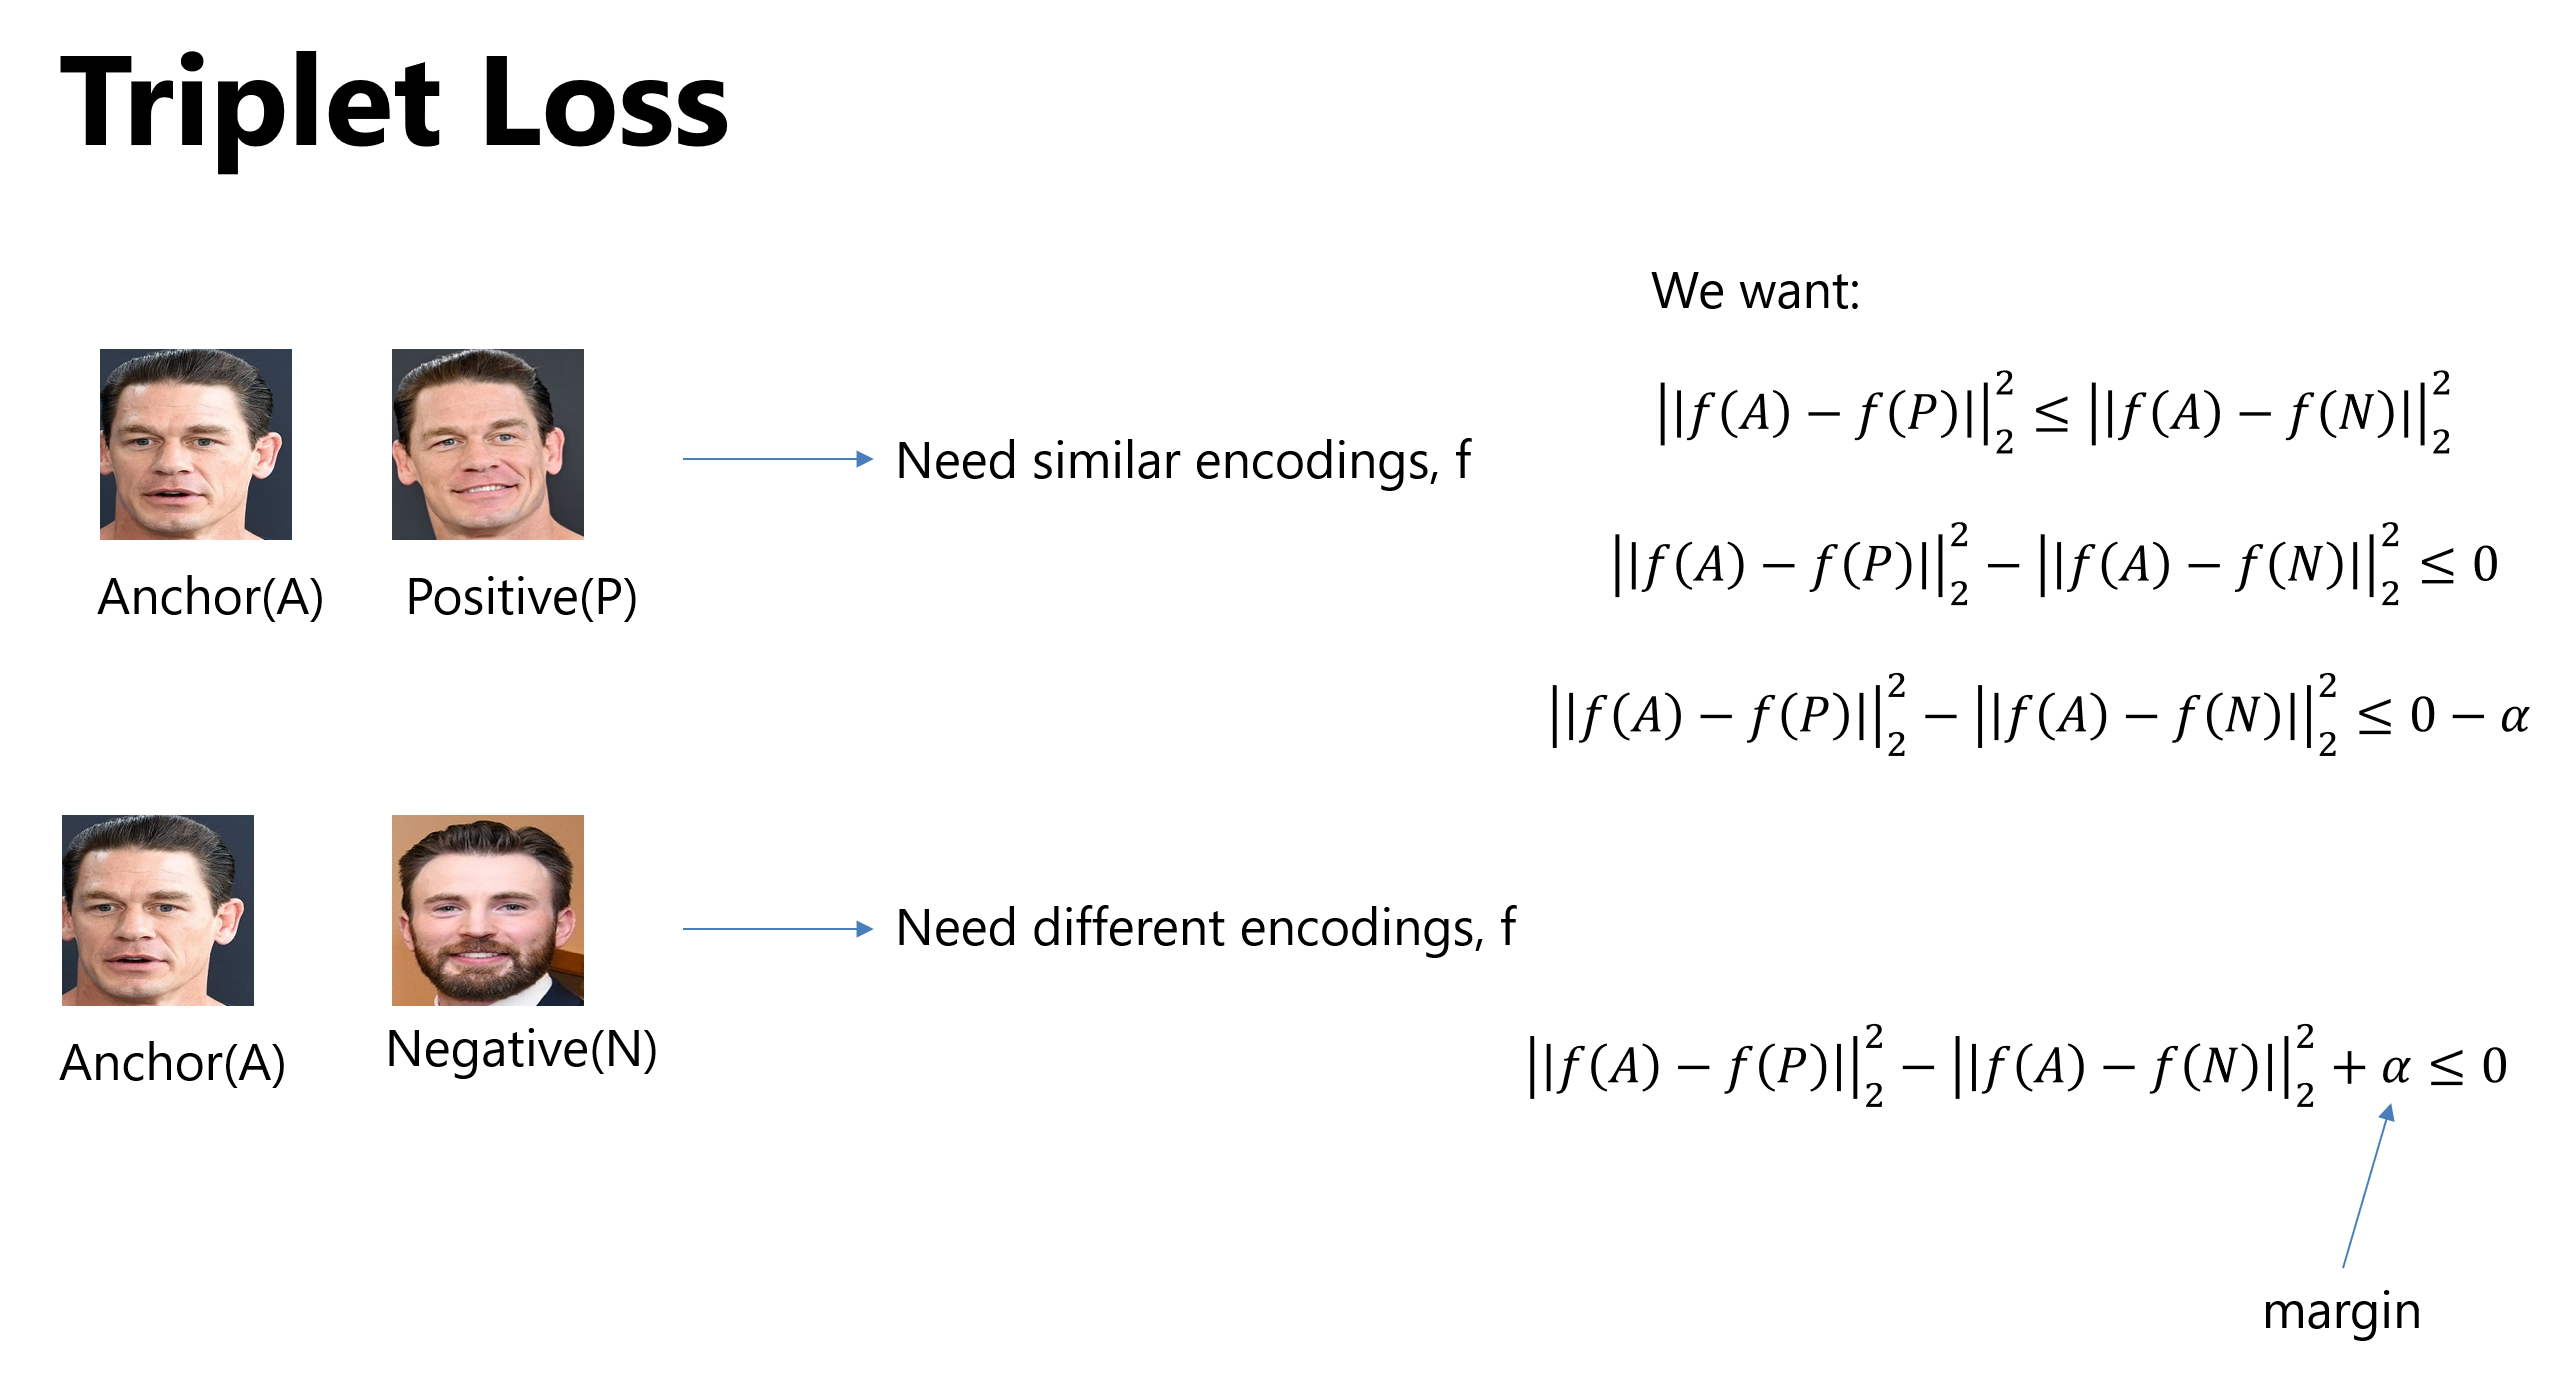

You'd like to make sure that an image $A^{(i)}$ of an individual is closer to the Positive $P^{(i)}$ than to the Negative image $N^{(i)}$) by at least a margin $\alpha$:

$$\mid \mid f(A^{(i)}) - f(P^{(i)}) \mid \mid_2^2 + \alpha < \mid \mid f(A^{(i)}) - f(N^{(i)}) \mid \mid_2^2$$

You would thus like to minimize the following "triplet cost":

$$\mathcal{J} = \sum^{N}_{i=1} \large[ \small \underbrace{\mid \mid f(A^{(i)}) - f(P^{(i)}) \mid \mid_2^2}_\text{(1)} - \underbrace{\mid \mid f(A^{(i)}) - f(N^{(i)}) \mid \mid_2^2}_\text{(2)} + \alpha \large ] \small_+ \tag{3}$$

Here, we are using the notation "$[z]_+$" to denote $max(z,0)$.  

Notes:
- The term (1) is the squared distance between the anchor "A" and the positive "P" for a given triplet; you want this to be small.
- The term (2) is the squared distance between the anchor "A" and the negative "N" for a given triplet, you want this to be relatively large, so it thus makes sense to have a minus sign preceding it.
- $\alpha$ is called the margin. It is a hyperparameter that you should pick manually. We will use $\alpha = 0.2$.

Most implementations also normalize the encoding vectors  to have norm equal one (i.e., $\mid \mid f(img)\mid \mid_2$=1); you won't have to worry about that here.

**Your task:** Implement the triplet loss as defined by formula (3). Here are the 4 steps:
1. Compute the distance between the encodings of "anchor" and "positive": $\mid \mid f(A^{(i)}) - f(P^{(i)}) \mid \mid_2^2$
2. Compute the distance between the encodings of "anchor" and "negative": $\mid \mid f(A^{(i)}) - f(N^{(i)}) \mid \mid_2^2$
3. Compute the formula per training example: $ \mid \mid f(A^{(i)}) - f(P^{(i)}) \mid - \mid \mid f(A^{(i)}) - f(N^{(i)}) \mid \mid_2^2 + \alpha$
3. Compute the full formula by taking the max with zero and summing over the training examples:
$$\mathcal{J} = \sum^{N}_{i=1} \large[ \small \mid \mid f(A^{(i)}) - f(P^{(i)}) \mid \mid_2^2 - \mid \mid f(A^{(i)}) - f(N^{(i)}) \mid \mid_2^2+ \alpha \large ] \small_+ \tag{3}$$

Useful hints:

* For the distance between the encodings of "anchor" and "positive" you can use `tf.reduce_sum()` and `tf.square()` functions with the appropriate arguments.  See details on these functions at https://www.tensorflow.org/api_docs/python/tf/math/reduce_sum and https://www.tensorflow.org/api_docs/python/tf/math/square, respectively.

* For calculating distance between the encodings of "anchor" and "negative" you can use a simlar expression as above.

* For computing the full formula by taking the max with zero and summing over the training examples you can use  `tf.maximum()`, see https://www.tensorflow.org/api_docs/python/tf/math/maximum

In [14]:
# Activity 2

def loss_function(x, alpha = 0.2):
    # Triplet Loss function.
    anchor,positive,negative = x


    # Distance between the anchor and the positive.
    # Use tf.reduce_sum and tf.square for element-wise squaring and summing along an axis.
    pos_dist = tf.reduce_sum(tf.square(anchor - positive), axis=1)
    # Distance between the anchor and the negative
    neg_dist = tf.reduce_sum(tf.square(anchor - negative), axis=1)

    # Triplet Loss Formula
    basic_loss = pos_dist - neg_dist + alpha
    loss = tf.maximum(basic_loss, 0.0)

    return loss

#**4. Model Training**

Let's define the training function. The `train()` function below is the training routine that uses automatic differentiation with `GradientTape` to compute gradients and update model parameters. It takes input data, generates predictions through the model, calculates loss, computes gradients of the loss with respect to trainable variables, applies these gradients using an optimizer, and returns the loss value - effectively encapsulating a single training step in our optimization process.

In [15]:
def train(X):
    with tf.GradientTape() as tape:
        y_pred = model(X)
        loss = loss_function(y_pred)
    grad = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grad, model.trainable_variables))
    return loss

In [16]:
tf.summary.trace_on(graph=True, profiler=False)
output = model([tf.zeros((32,224,224,3)), tf.zeros((32,224,224,3)), tf.zeros((32,224,224,3))])
with writer.as_default():
    tf.summary.trace_export(name="my_func_trace", step=0, profiler_outdir=logdir)
tf.summary.trace_off()

In [17]:
# Debugging - checking to see if path exists
import os
os.path.exists('./dataset')

True

Run the following cell to construct `data_generator` class instance and generate the triplets `(a, p, n)`.

In [18]:
data_generator = DataGenerator(dataset_path='./dataset')
a, p, n = data_generator[0]

In [19]:
checkpoint = tf.train.Checkpoint(model=model)

The following cell will start the model training. It might take around 20-25 minutes to train based on the GPU selected by google colab.

In [20]:
losses = []
accuracy = []

# Set up the file writer for TensorBoard
logdir = "./logs/scalars/"
file_writer = tf.summary.create_file_writer(logdir)

no_of_batches = data_generator.__len__()
for i in range(1, epochs+1, 1):
    loss = 0
    with tqdm(total=no_of_batches) as pbar:

        description = "Epoch " + str(i) + "/" + str(epochs)
        pbar.set_description_str(description)

        for j in range(no_of_batches):
            data = data_generator[j]
            temp = train(data)
            #loss += temp
            # Calculate the average loss for the batch
            batch_loss = tf.reduce_mean(temp)
            loss += batch_loss

            pbar.update()
            print_statement = "Loss :" + str(temp.numpy())
            pbar.set_postfix_str(print_statement)

        loss /= no_of_batches
        losses.append(loss.numpy())
        with file_writer.as_default():
            tf.summary.scalar('Loss', data=loss.numpy(), step=i)

        print_statement = "Loss :" + str(loss.numpy())

        pbar.set_postfix_str(print_statement)

checkpoint.save(checkpoint_path)
print("Checkpoint Saved")

Epoch 1/5:   3%|▎         | 1/31 [00:13<06:40, 13.36s/it, Loss :[0.         0.         0.         0.22145946 0.         0.
 0.2635998  0.         0.         0.         0.         0.
Epoch 1/5:   6%|▋         | 2/31 [00:14<02:51,  5.91s/it, Loss :[0.         0.         0.         0.22145946 0.         0.
 0.2635998  0.         0.         0.         0.         0.
Epoch 1/5:   6%|▋         | 2/31 [00:14<02:51,  5.91s/it, Loss :[0.         0.         0.         0.         0.04845197 0.
 0.         0.         0.         0.09117766 0.42635638 0.
Epoch 1/5:  10%|▉         | 3/31 [00:15<01:44,  3.74s/it, Loss :[0.         0.         0.         0.         0.04845197 0.
 0.         0.         0.         0.09117766 0.42635638 0.
Epoch 1/5:  10%|▉         | 3/31 [00:15<01:44,  3.74s/it, Loss :[0.15006573 0.17848869 0.13629134 0.         0.         0.
 0.         0.         0.         0.         0.         0.
Epoch 1/5:  13%|█▎        | 4/31 [00:16<01:13,  2.73s/it, Loss :[0.15006573 0.17848869 0.1

Checkpoint Saved


**Expected Output**:

<table>
    <tr>
        <td>
            **loss**
        </td>
        <td>
            0.03...
        </td>
    </tr>

</table>

# **5. Create the Face Database**

A folder named `images` is included in the root directory. The folder contains images for testing.

Running the next three cell will prepare the model we just trained for prediction using the checkpoint path.

In [21]:
_ = model([tf.zeros((32,224,224,3)), tf.zeros((32,224,224,3)), tf.zeros((32,224,224,3))])
_ = model.get_features(tf.zeros((32,224,224,3)))

In [22]:
#base_dir = "."
checkpoint_path = "./logs/model/checkpoint"

In [23]:
checkpoint = tf.train.Checkpoint(model=model)

Run the following cell to import library for input/test images.

In [24]:
from PIL import Image
from numpy import asarray


First we will build a database containing one encoding vector for each person we want to recognise by our system. To generate the encoding we use `img_to_encoding(image_path, model)` function which basically runs the forward propagation of the model on the specified image.

In [25]:
def img_to_encoding(image_path, model):
    img1 = cv2.imread(image_path, 1)
    img = img1[...,::-1]
    img = np.around(np.transpose(img, (2,0,1))/255.0, decimals=12)
    img = np.moveaxis(img, 0, -1)
    x_train = np.array([img])
    embedding = model.get_features(x_train)
    return embedding

Run the following code to build the database (represented as a python dictionary). This database maps each person's name to a 128-dimensional encoding of their faces.

In [26]:
database = {}
database["Bryan"] = img_to_encoding("images/Bryan.jpg", model)
database["Benedict"] = img_to_encoding("images/Benedict.jpg", model)
database["Chris"] = img_to_encoding("images/Chris.jpg", model)
database["Depp"] = img_to_encoding("images/Depp.jpg", model)
database["Gus"] = img_to_encoding("images/Gus.jpg", model)
database["John"] = img_to_encoding("images/John.jpg", model)


#**6.Face Recognition App**

Next, you will implement a face recognition app that takes as input an image, and figures out if it is one of the authorized persons recorded in the database.

Your task is to implement `recognize_the_face()`. You will have to go through the following steps:
1. Compute the target encoding of the image from `image_path`
2. Find the encoding from the database that has smallest distance with the target encoding.
    - Initialize the `min_dist` variable to a large enough number (100). It will help you keep track of what is the closest encoding to the input's encoding.
    - Loop over the database dictionary's names and encodings. To loop use `for (name, db_enc) in database.items()`.
        - Compute L2 distance between the target "encoding" and the current "encoding" from the database.
        - If this distance is less than the min_dist, then set min_dist to dist, and identity to name.

In [27]:
# Activity 3

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
from google.colab.patches import cv2_imshow


def recognize_the_face(image_path, database, model):
    """
    Implements face recognition by finding who is the person on the image_path image.

    Arguments:
    image_path -- path to an image
    database -- database containing image encodings along with the name of the person on the image
    model -- your Inception model instance in Keras

    Returns:
    min_dist -- the minimum distance between image_path encoding and the encodings from the database
    identity -- string, the name prediction for the person on image_path
    """


    ## Step 1: Compute the target "encoding" for the image. Use img_to_encoding() see example above.
    encoding = img_to_encoding(image_path, model)

    ## Step 2: Find the closest encoding ##

    # Initialize "min_dist" to a large value, say 100
    min_dist = 100

    # Loop over the database dictionary's names and encodings.
    for (name, db_enc) in database.items():

        # Compute L2 distance between the target "encoding" and the current "feature" from the database (database[name]). np.linalg.norm may be useful
        dist = np.linalg.norm(encoding - db_enc, ord=None, axis=None, keepdims=False)

        # If this distance is less than the min_dist, then set min_dist to dist, and identity to name.
        if (dist < min_dist):
            min_dist = dist
            identity = name


    if min_dist > 0.6:
        print("Not in the database. Hence the entry is not allowed!")
    else:
        print ("it's " + str(identity) + ", the distance is " + str(min_dist))

    return min_dist, identity

Suppose John is at the front-door and the camera takes a picture of him ("images/john2.jpg"). Let's see whether your `recognize_the_face()` algorithm identifies John.

it's John, the distance is 0.4549755


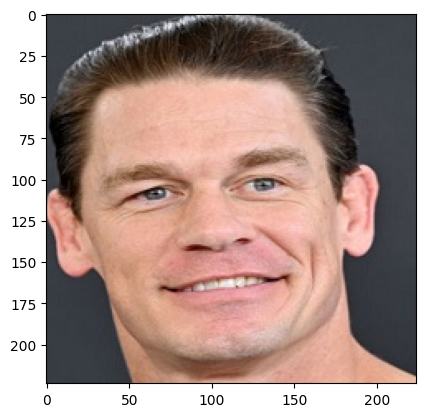

In [28]:
recognize_the_face("images/John2.jpg", database, model)
img= plt.imread("images/John2.jpg")
plt.imshow(img)

**Expected Output**:

<table>
    <tr>
        <td>
            **it's John, the distance is 0.24..**
        </td>
        <td>
           (0.24..., 'John')
        </td>
    </tr>

</table>

Let us try the app with Depp's face.

it's Depp, the distance is 0.0


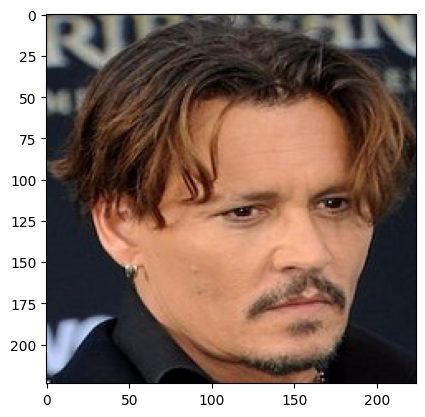

In [29]:
recognize_the_face("images/Depp.jpg", database, model)
img= plt.imread("images/Depp.jpg")
plt.imshow(img)

Suppose Taylor is at the front-door and the camera takes a picture of him ("images/taylor.jpg"). He is not in the stored database. Let us see what your `recognize_the_face()` algorithm will return.

In [30]:
recognize_the_face("images/taylor.jpg", database, model)

Not in the database. Hence the entry is not allowed!


(1.2594154, 'John')

**What you should remember**:
- Face verification solves an easier 1:1 matching problem; face recognition addresses a harder 1:K matching problem.
- The triplet loss is an effective loss function for training a neural network to learn an encoding of a face image.
- The same encoding can be used for verification and recognition. Measuring distances between two images' encodings allows you to determine whether they are pictures of the same person.

**Congrats** on finishing this assignment!


#**7. Evaluation Details**
The assignment will be discussed in the recitations on Nov. 27 and Dec. 4. You will get a total of 12 days to complete the activities. Attendance in each recitation is mandatory to get marks for the graded activities. We will record your attendance. If you complete all the activities in the first recitation itself, then the second recitation is optional. You have to read the instructions, refer to the slides and do all the exercises. The marker reserves the prerogative to pose supplementary questions for elucidation when deemed necessary.

**NOTE:** If you are unable to attend the recitation, please notify the instructor prior to the session. Absences due to illness or other valid reasons will be taken into consideration.

#**8. References**

1. Florian Schroff, Dmitry Kalenichenko, James Philbin (2015). [FaceNet: A Unified Embedding for Face Recognition and Clustering](https://arxiv.org/pdf/1503.03832.pdf)
2. Yaniv Taigman, Ming Yang, Marc'Aurelio Ranzato, Lior Wolf (2014). [DeepFace: Closing the gap to human-level performance in face verification](https://research.fb.com/wp-content/uploads/2016/11/deepface-closing-the-gap-to-human-level-performance-in-face-verification.pdf)

3. Q. Cao, L. Shen, W. Xie, O. M. Parkhi, A. Zisserman
[VGGFace2: A dataset for recognising faces across pose and age ](https://www.robots.ox.ac.uk/~vgg/data/vgg_face2/)
International Conference on Automatic Face and Gesture Recognition, 2018

